In [86]:
from src.ingest import engine
from src.load_data import load_joined_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
pd.set_option('display.width',230)

## Ingestion

In [87]:
query = "SELECT name FROM sqlite_master where type = 'table'"
tables = pd.read_sql(query,engine)
for table in tables["name"]:
    query = f"SELECT * from {table}"
    query_df = pd.read_sql(query,engine)
    print("=="*110)
    print(f"Table Name: {table.capitalize()}, Shape: {query_df.shape}")
    print("=="*110)
    print(query_df.head())

Table Name: Sellers, Shape: (3095, 4)
                          seller_id  seller_zip_code_prefix        seller_city seller_state
0  3442f8959a84dea7ee197c632cb2df15                   13023           campinas           SP
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844         mogi guacu           SP
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031     rio de janeiro           RJ
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195          sao paulo           SP
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914  braganca paulista           SP
Table Name: Product_category_name_translation, Shape: (71, 2)
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
Table Name: 

In [88]:
master_df = load_joined_data(engine)
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    118310 non-null  str    
 1   customer_unique_id             118310 non-null  str    
 2   customer_zip_code_prefix       118310 non-null  int64  
 3   customer_city                  118310 non-null  str    
 4   customer_state                 118310 non-null  str    
 5   order_id                       118310 non-null  str    
 6   order_status                   118310 non-null  str    
 7   order_purchase_timestamp       118310 non-null  str    
 8   order_approved_at              118295 non-null  str    
 9   order_delivered_carrier_date   117056 non-null  str    
 10  order_delivered_customer_date  115722 non-null  str    
 11  order_estimated_delivery_date  118310 non-null  str    
 12  order_item_id                  118310 non

## EDA
### RFM Segmentation using KMeans Clustering

In [89]:
master_df["order_purchase_timestamp"] = pd.to_datetime(master_df["order_purchase_timestamp"])
snap_date = max(master_df["order_purchase_timestamp"])+ pd.Timedelta(1,'D')
rfm = master_df.groupby('customer_unique_id').agg(
    recency = ('order_purchase_timestamp',lambda x: (snap_date-x.max()).days),
    frequency = ('order_id','nunique'),
    monetary  = ('price','sum')
    ).reset_index(drop=True)
# Descriptive summary
print("=="*20)
print("Base RFM Metrics Summary")
print("=="*20)
print(rfm.describe().round(2))

Base RFM Metrics Summary
        recency  frequency  monetary
count  95420.00   95420.00  95420.00
mean     243.60       1.03    149.59
std      153.16       0.21    249.93
min        1.00       1.00      0.85
25%      119.00       1.00     48.90
50%      224.00       1.00     89.90
75%      353.00       1.00    159.90
max      729.00      16.00  13440.00


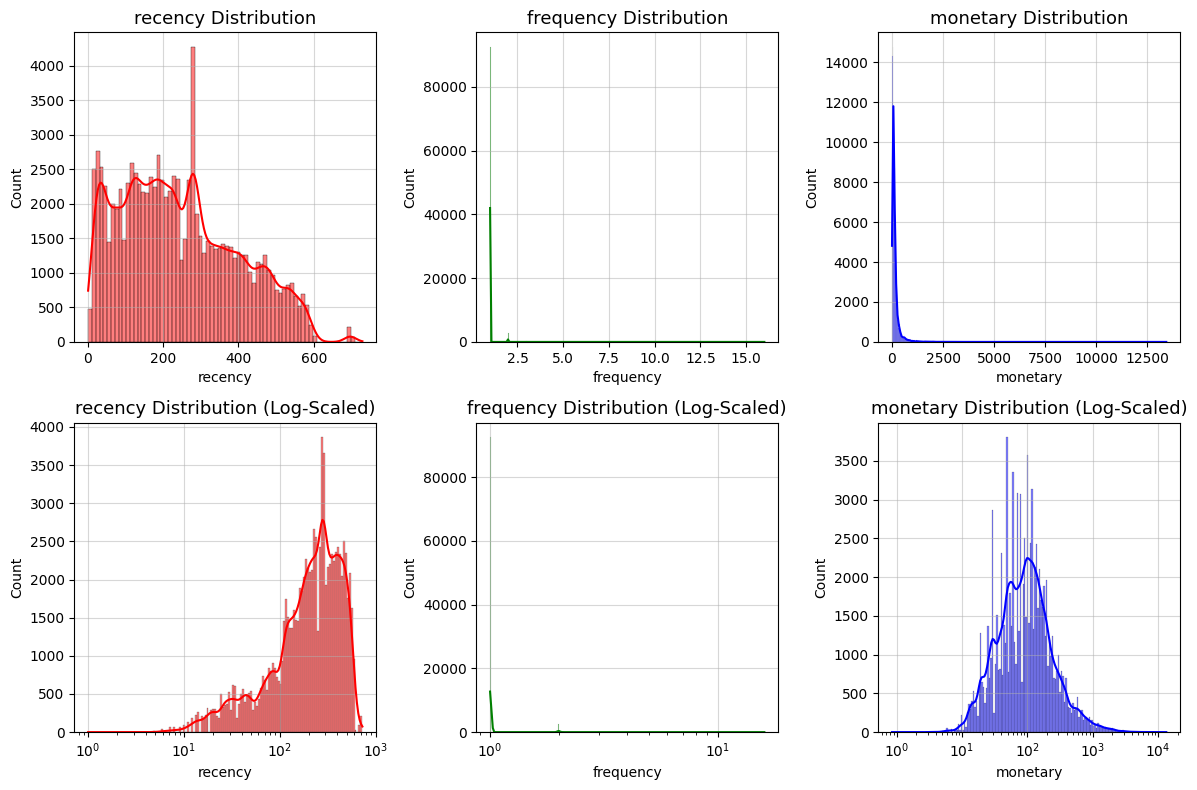

In [90]:
fig,axes = plt.subplots(2,3,figsize=(12,8))
sns.histplot(x="recency",data=rfm,color="red",
             kde=True,ax=axes[0,0])
sns.histplot(x="frequency",data=rfm,color="green",
             kde=True,ax=axes[0,1])
sns.histplot(x="monetary",data=rfm,color="blue",
             kde=True,ax=axes[0,2])
sns.histplot(x="recency",data=rfm,color="red",kde=True,
             log_scale=True,ax=axes[1,0])
sns.histplot(x="frequency",data=rfm,color="green",kde=True,
             log_scale=True,ax=axes[1,1])
sns.histplot(x="monetary",data=rfm,color="blue",
             kde=True,log_scale=True,ax=axes[1,2])
axes[0,0].set_title('recency Distribution',fontsize=13)
axes[0,0].grid(alpha=0.5)
axes[0,1].set_title('frequency Distribution',fontsize=13)
axes[0,1].grid(alpha=0.5)
axes[0,2].set_title('monetary Distribution',fontsize=13)
axes[0,2].grid(alpha=0.5)
axes[1,0].set_title('recency Distribution (Log-Scaled)',fontsize=13)
axes[1,0].grid(alpha=0.5)
axes[1,1].set_title('frequency Distribution (Log-Scaled)',fontsize=13)
axes[1,1].grid(alpha=0.5)
axes[1,2].set_title('monetary Distribution (Log-Scaled)',fontsize=13)
axes[1,2].grid(alpha=0.5)
plt.tight_layout()
plt.show()

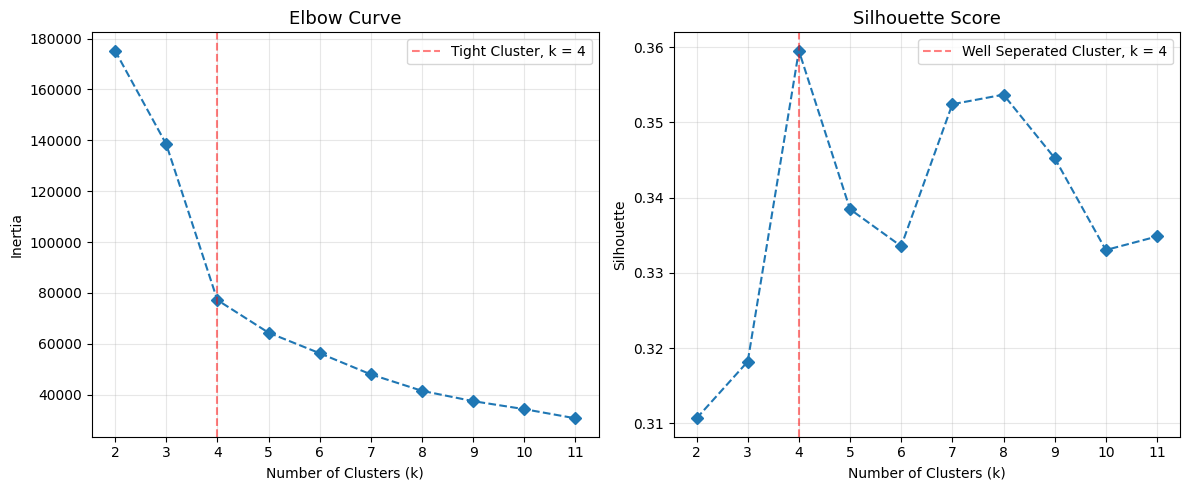

In [91]:
# Log transformation
X = rfm[['recency', 'frequency', 'monetary']].copy()
X['monetary']  = np.log1p(X['monetary'])

# train-test split with 80% train set, random state for reproducibility
X_train,X_test = train_test_split(X, test_size=0.2,random_state=42)

# Standardization - fit only on train set to ensure no data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform only on test set
X_test_scaled = scaler.transform(X_test)

# Loops
inertia = []
silhouette =[]
for cluster in range(2,12): # Silhouette need at least two cluster.
    kmeans = KMeans(n_clusters = cluster,random_state = 42)
    kmeans.fit(X_train_scaled) 
    inertia.append(kmeans.inertia_)
    test_label = kmeans.predict(X_test_scaled) # Predicted lables
    silhouette.append(silhouette_score(X_test_scaled,test_label)) 
fig,axis = plt.subplots(1,2,figsize=(12,5))
axis[0].plot(range(2,12),inertia,marker='D',linestyle='--')
axis[1].plot(range(2,12),silhouette,marker='D',linestyle='--')
axis[0].set_xlabel("Number of Clusters (k)")
axis[0].set_ylabel("Inertia")
axis[0].set_title("Elbow Curve",fontsize=13)
axis[0].set_xticks(range(2,12))
axis[1].set_xticks(range(2,12))
axis[0].axvline(x=4,color='r',linestyle='--',alpha=0.5,label="Tight Cluster, k = 4")
axis[0].legend()
axis[1].axvline(x=4,color='r',linestyle='--',alpha=0.5,label="Well Seperated Cluster, k = 4")
axis[1].legend()
axis[0].grid(alpha=0.3)
axis[1].grid(alpha=0.3)
axis[1].set_title("Silhouette Score",fontsize=13)
axis[1].set_xlabel("Number of Clusters (k)")
axis[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig('outputs/elbow_silhouette_validation.png')
plt.show()

In [92]:
final_kmeans = KMeans(n_clusters = 4, random_state=42)
final_kmeans.fit(X_train_scaled)
final_train_labels = final_kmeans.labels_ # Predicted labels on train dataset
final_test_labels  = final_kmeans.predict(X_test_scaled)

# assign labels back to rfm tables with right index
rfm.loc[X_train.index,'KMeans_Segment'] = final_train_labels
rfm.loc[X_test.index,'KMeans_Segment']  =  final_test_labels
rfm['KMeans_Segment'] = rfm['KMeans_Segment'].astype(int)
display(rfm.groupby('KMeans_Segment').agg(
    recency=('recency','mean'),
    frequency=('frequency','mean'),
    monetary=('monetary','mean'),
    count=('monetary','count')
).round(2).sort_values('recency'))

,recency,frequency,monetary,count
KMeans_Segment,,,,
2,161.15,1.00,45.13,31756
1,166.08,1.00,264.05,33175
3,226.20,2.11,293.70,2913
0,433.65,1.00,116.96,27576


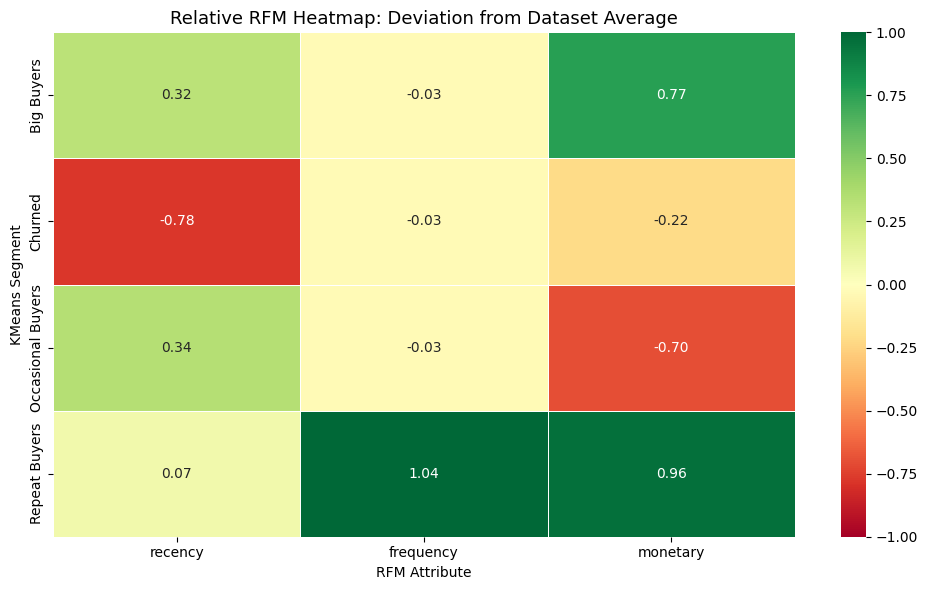

In [95]:
# Mapping the Segemnt according to business interpretation
rfm['KMeans_Segment_name'] = rfm['KMeans_Segment'].map({2:'Occasional Buyers', # bought once, low spend
                              0: 'Churned', # 14 months gone
                              3: 'Repeat Buyers', # only true loyal segment
                              1: 'Big Buyers' # bought once, high spend
                              })
# Cluster Average
cluster_avg = rfm.groupby('KMeans_Segment_name').agg({"recency":"mean","frequency":"mean","monetary":"mean"})
# Population Average
population_avg = rfm[["recency", "frequency", "monetary"]].mean()
# Related Importance
relative_imp = cluster_avg/population_avg - 1
# Flipped the recency - lower better for meaningful plot
relative_imp_flipped = relative_imp.copy()
relative_imp_flipped['recency'] = -relative_imp['recency']
plt.figure(figsize=(10,6))
sns.heatmap(relative_imp_flipped, annot=True, fmt='.2f', cmap='RdYlGn',
             center=0,linewidths=0.5, vmin=-1, vmax=1)
plt.title("Relative RFM Heatmap: Deviation from Dataset Average", fontsize=13)
plt.xlabel('RFM Attribute')
plt.ylabel('KMeans Segment')
plt.tight_layout()
plt.savefig('outputs/segment_relative_importance_heatmap.png')
plt.show()